# Feature Importance Evolution Analysis

This notebook analyzes how feature importance rankings evolve over time during walk-forward training.

**Key Visualizations:**
- Rank evolution heatmap for top features
- Feature importance trends over time
- Feature stability metrics
- Top 20 features ranking changes

**Configuration:**
- Set `FOCUS_ON_FUNDAMENTALS = True` in cell 1 to exclude price/market cap features (RefPriceClose_lag1, CompanyMarketCap_lag1) and focus on fundamental feature analysis

## 1. Setup and Imports

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# ============================================================================
# GLOBAL CONFIGURATION FLAGS
# ============================================================================

# Set to True to exclude price/market cap lagged features and focus on fundamentals
FOCUS_ON_FUNDAMENTALS = False

# Features to exclude when FOCUS_ON_FUNDAMENTALS = True
EXCLUDED_PRICE_FEATURES = [
    'RefPriceClose_lag1',
    'CompanyMarketCap_lag1',
    'CompanyMarketCap_lag1_rank',
]

# ============================================================================

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

# Figure settings
plt.rcParams['figure.figsize'] = (16, 10)
plt.rcParams['font.size'] = 10
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

print("✅ Imports complete")
if FOCUS_ON_FUNDAMENTALS:
    print(f"🎯 FOCUS MODE: Excluding {len(EXCLUDED_PRICE_FEATURES)} price/market cap features")
    for feat in EXCLUDED_PRICE_FEATURES:
        print(f"   ❌ {feat}")
else:
    print("📊 FULL MODE: Analyzing all features")

## 2. Auto-Detect Latest Feature Importance File

In [2]:
def find_latest_feature_importance(directory='logs'):
    """
    Find the most recent feature_importance_*.csv file by timestamp in filename.
    
    Expected format: feature_importance_YYYYMMDD_HHMMSS.csv
    
    Returns:
        Path: Path to newest file
    """
    base_dir = Path('.') / directory
    pattern = 'feature_importance_*.csv'
    
    files = list(base_dir.glob(pattern))
    
    if not files:
        raise FileNotFoundError(f"No {pattern} files found in {base_dir}")
    
    # Extract timestamp from filename: feature_importance_YYYYMMDD_HHMMSS.csv
    def extract_timestamp(filepath):
        stem = filepath.stem  # Remove .csv
        parts = stem.split('_')  # ['feature', 'importance', 'YYYYMMDD', 'HHMMSS']
        if len(parts) >= 4:
            date_str = parts[2]  # YYYYMMDD
            time_str = parts[3]  # HHMMSS
            timestamp_str = date_str + time_str
            return datetime.strptime(timestamp_str, '%Y%m%d%H%M%S')
        return datetime.min
    
    # Sort by timestamp (newest first)
    files_sorted = sorted(files, key=extract_timestamp, reverse=True)
    newest_file = files_sorted[0]
    
    print(f"📂 Found {len(files)} feature importance files")
    print(f"✅ Using newest: {newest_file.name}")
    print(f"   Timestamp: {extract_timestamp(newest_file).strftime('%Y-%m-%d %H:%M:%S')}")
    
    return newest_file

# Auto-detect latest file
feature_importance_file = find_latest_feature_importance()
print(f"\n📄 File path: {feature_importance_file}")

📂 Found 2 feature importance files
✅ Using newest: feature_importance_20260122_060541.csv
   Timestamp: 2026-01-22 06:05:41

📄 File path: logs/feature_importance_20260122_060541.csv


## 3. Load and Inspect Data

In [ ]:
# Load feature importance data
df = pd.read_csv(feature_importance_file)

# Apply feature filtering if FOCUS_ON_FUNDAMENTALS is enabled
if FOCUS_ON_FUNDAMENTALS:
    original_count = len(df)
    original_features = df['Feature'].nunique()
    
    # Remove excluded features
    df = df[~df['Feature'].isin(EXCLUDED_PRICE_FEATURES)].copy()
    
    filtered_count = len(df)
    filtered_features = df['Feature'].nunique()
    
    print(f"🎯 FILTER APPLIED:")
    print(f"   Rows: {original_count:,} → {filtered_count:,} (-{original_count - filtered_count:,})")
    print(f"   Features: {original_features} → {filtered_features} (-{original_features - filtered_features})")
    print()

print(f"📊 Data Shape: {df.shape[0]:,} rows, {df.shape[1]} columns")
print(f"📅 Time Range: {df['Month'].min()} to {df['Month'].max()}")
print(f"🔢 Unique Months: {df['Month'].nunique()}")
print(f"🎯 Unique Features: {df['Feature'].nunique()}")
print(f"\n📋 Sample Data:")
df.head(20)

In [4]:
# Summary statistics
print("📈 Summary Statistics:\n")
print(f"Total months with data: {df['Month'].nunique()}")
print(f"Total unique features tracked: {df['Feature'].nunique()}")
print(f"Features per month: {df.groupby('Month')['Feature'].count().mean():.1f} (avg)")
print(f"Importance range: {df['Importance'].min():.6f} to {df['Importance'].max():.6f}")

# Top 10 most stable features (appear in top 20 most frequently)
top20_mask = df['Rank'] <= 20
feature_appearances = df[top20_mask]['Feature'].value_counts().head(10)
print(f"\n🏆 Top 10 Most Stable Features (appear in top 20 most frequently):\n")
for i, (feature, count) in enumerate(feature_appearances.items(), 1):
    pct = (count / df['Month'].nunique()) * 100
    print(f"{i:2d}. {feature:50s} - {count:3d}/{df['Month'].nunique()} months ({pct:5.1f}%)")

📈 Summary Statistics:

Total months with data: 193
Total unique features tracked: 192
Features per month: 20.0 (avg)
Importance range: 0.005369 to 0.584382

🏆 Top 10 Most Stable Features (appear in top 20 most frequently):

 1. RefPriceClose_lag1                                 - 189/193 months ( 97.9%)
 2. sharadar_scalemarketcap                            - 167/193 months ( 86.5%)
 3. volatility_20d                                     - 156/193 months ( 80.8%)
 4. CompanyMarketCap_lag1                              - 142/193 months ( 73.6%)
 5. return_20d                                         - 133/193 months ( 68.9%)
 6. volatility_20d_rank                                - 126/193 months ( 65.3%)
 7. GICSSectorName                                     - 111/193 months ( 57.5%)
 8. Estpricegrowth_percent                             - 110/193 months ( 57.0%)
 9. totalassets_fmp                                    - 108/193 months ( 56.0%)
10. roa_rank                                   

## 4. Feature Ranking Evolution Heatmap

This heatmap shows how the rankings of top features change over time. Darker colors indicate better (lower) ranks.

In [ ]:
# Get top N features that appear most frequently in top 20
N_TOP_FEATURES = 30
top20_mask = df['Rank'] <= 20
top_features = df[top20_mask]['Feature'].value_counts().head(N_TOP_FEATURES).index.tolist()

# Filter data for these features
df_top = df[df['Feature'].isin(top_features)].copy()

# Pivot to create heatmap data (Month x Feature)
heatmap_data = df_top.pivot(index='Feature', columns='Month', values='Rank')

# Sort features by average rank
heatmap_data['avg_rank'] = heatmap_data.mean(axis=1)
heatmap_data = heatmap_data.sort_values('avg_rank')
heatmap_data = heatmap_data.drop('avg_rank', axis=1)

# Create heatmap
fig, ax = plt.subplots(figsize=(20, 12))

# Reverse colormap so dark = better rank (lower number)
sns.heatmap(heatmap_data, 
            cmap='RdYlGn_r',  # Red (bad/high rank) to Green (good/low rank)
            annot=False,
            fmt='.0f',
            cbar_kws={'label': 'Rank (1=Best)'},
            linewidths=0.5,
            vmin=1,
            vmax=50,
            ax=ax)

# Add mode indicator to title
mode_text = " [FUNDAMENTALS FOCUS]" if FOCUS_ON_FUNDAMENTALS else " [ALL FEATURES]"
ax.set_title(f'Feature Ranking Evolution Over Time (Top {N_TOP_FEATURES} Most Stable Features){mode_text}\n' +
             f'Green = Top Ranked, Red = Lower Ranked',
             fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Training Month', fontsize=14, fontweight='bold')
ax.set_ylabel('Feature', fontsize=14, fontweight='bold')

# Rotate x-axis labels for readability
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)

plt.tight_layout()
plt.show()

print(f"\n💡 Interpretation:")
print(f"   • Green bands = Feature is highly ranked (important) in those months")
print(f"   • Red bands = Feature rank dropped (less important)")
print(f"   • White/missing = Feature not in top 50 for that month")
print(f"   • Horizontal consistency = Stable feature importance")
print(f"   • Vertical changes = Market regime shifts")

## 5. Top 20 Features - Rank Position Over Time

Line chart showing how the top 20 most stable features move in ranking over time.

In [ ]:
# Get top 20 most stable features
N_FEATURES_PLOT = 20
top20_mask = df['Rank'] <= 20
stable_features = df[top20_mask]['Feature'].value_counts().head(N_FEATURES_PLOT).index.tolist()

# Filter data
df_stable = df[df['Feature'].isin(stable_features)].copy()

# Convert Month to datetime for better plotting
df_stable['MonthDate'] = pd.to_datetime(df_stable['Month'] + '-01')

# Create plot
fig, ax = plt.subplots(figsize=(20, 10))

# Plot each feature as a line
for feature in stable_features:
    feature_data = df_stable[df_stable['Feature'] == feature].sort_values('MonthDate')
    ax.plot(feature_data['MonthDate'], 
            feature_data['Rank'],
            marker='o',
            markersize=3,
            linewidth=2,
            label=feature,
            alpha=0.7)

# Invert y-axis (rank 1 at top)
ax.invert_yaxis()
ax.set_ylim(50, 0)

# Add horizontal lines for reference
ax.axhline(y=1, color='green', linestyle='--', alpha=0.3, linewidth=1)
ax.axhline(y=10, color='orange', linestyle='--', alpha=0.3, linewidth=1)
ax.axhline(y=20, color='red', linestyle='--', alpha=0.3, linewidth=1)

# Add mode indicator to title
mode_text = " [FUNDAMENTALS FOCUS]" if FOCUS_ON_FUNDAMENTALS else " [ALL FEATURES]"
ax.set_title(f'Feature Rank Evolution Over Time (Top {N_FEATURES_PLOT} Most Stable Features){mode_text}\n' +
             'Lower = Better Rank',
             fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Training Month', fontsize=14, fontweight='bold')
ax.set_ylabel('Rank (1 = Most Important)', fontsize=14, fontweight='bold')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9, framealpha=0.9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n💡 Interpretation:")
print(f"   • Lines closer to top (rank 1) = More important features")
print(f"   • Flat lines = Stable importance over time")
print(f"   • Sharp changes = Feature importance shifts (market regime change)")

## 6. Feature Importance Score Over Time

Shows absolute importance scores (not just ranks) for top features.

In [ ]:
# Get top 15 features by average importance score
N_FEATURES_IMP = 15
avg_importance = df.groupby('Feature')['Importance'].mean().sort_values(ascending=False)
top_importance_features = avg_importance.head(N_FEATURES_IMP).index.tolist()

# Filter data
df_imp = df[df['Feature'].isin(top_importance_features)].copy()
df_imp['MonthDate'] = pd.to_datetime(df_imp['Month'] + '-01')

# Create plot
fig, ax = plt.subplots(figsize=(20, 10))

# Plot each feature
for feature in top_importance_features:
    feature_data = df_imp[df_imp['Feature'] == feature].sort_values('MonthDate')
    ax.plot(feature_data['MonthDate'], 
            feature_data['Importance'],
            marker='o',
            markersize=3,
            linewidth=2,
            label=feature,
            alpha=0.7)

# Add mode indicator to title
mode_text = " [FUNDAMENTALS FOCUS]" if FOCUS_ON_FUNDAMENTALS else " [ALL FEATURES]"
ax.set_title(f'Feature Importance Score Evolution (Top {N_FEATURES_IMP} by Average Importance){mode_text}\n' +
             'Higher = More Important',
             fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Training Month', fontsize=14, fontweight='bold')
ax.set_ylabel('Importance Score', fontsize=14, fontweight='bold')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9, framealpha=0.9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n💡 Interpretation:")
print(f"   • Higher values = Model relies more on this feature")
print(f"   • Score changes = Feature utility shifts with market conditions")

## 7. Feature Stability Analysis

Quantifies which features have most consistent rankings over time.

In [8]:
# Calculate stability metrics for each feature
stability_metrics = []

for feature in df['Feature'].unique():
    feature_data = df[df['Feature'] == feature]
    
    # Only analyze if feature appears in at least 25% of months
    min_appearances = df['Month'].nunique() * 0.25
    if len(feature_data) < min_appearances:
        continue
    
    metrics = {
        'Feature': feature,
        'Appearances': len(feature_data),
        'Appearance_Pct': (len(feature_data) / df['Month'].nunique()) * 100,
        'Avg_Rank': feature_data['Rank'].mean(),
        'Median_Rank': feature_data['Rank'].median(),
        'Std_Rank': feature_data['Rank'].std(),
        'Min_Rank': feature_data['Rank'].min(),
        'Max_Rank': feature_data['Rank'].max(),
        'Rank_Range': feature_data['Rank'].max() - feature_data['Rank'].min(),
        'Avg_Importance': feature_data['Importance'].mean(),
        'Top10_Count': (feature_data['Rank'] <= 10).sum(),
        'Top20_Count': (feature_data['Rank'] <= 20).sum(),
    }
    
    stability_metrics.append(metrics)

df_stability = pd.DataFrame(stability_metrics)

# Sort by stability (low std_rank = more stable)
df_stability = df_stability.sort_values('Std_Rank')

print("📊 MOST STABLE FEATURES (Low Rank Variance)\n")
print(df_stability.head(20).to_string(index=False))

print("\n" + "="*100 + "\n")

# Sort by average rank (best performers)
df_best = df_stability.sort_values('Avg_Rank').head(20)
print("🏆 BEST AVERAGE PERFORMERS (Consistently Highly Ranked)\n")
print(df_best.to_string(index=False))

📊 MOST STABLE FEATURES (Low Rank Variance)

                                     Feature  Appearances  Appearance_Pct  Avg_Rank  Median_Rank  Std_Rank  Min_Rank  Max_Rank  Rank_Range  Avg_Importance  Top10_Count  Top20_Count
                          RefPriceClose_lag1          189       97.927461  2.804233          2.0  2.515650         1        14          13        0.148995          185          189
                             return_20d_rank           63       32.642487 11.650794         12.0  4.205061         4        20          16        0.021729           25           63
                                  return_10d           69       35.751295 12.884058         14.0  4.206215         3        20          17        0.024369           22           69
                                    ltg_rank           54       27.979275 11.055556         12.0  4.561598         2        20          18        0.023955           24           54
                   totalnoncurrentassets_fmp       

## 8. Monthly Top 5 Features Evolution

Bar chart race style visualization showing top 5 features for each month.

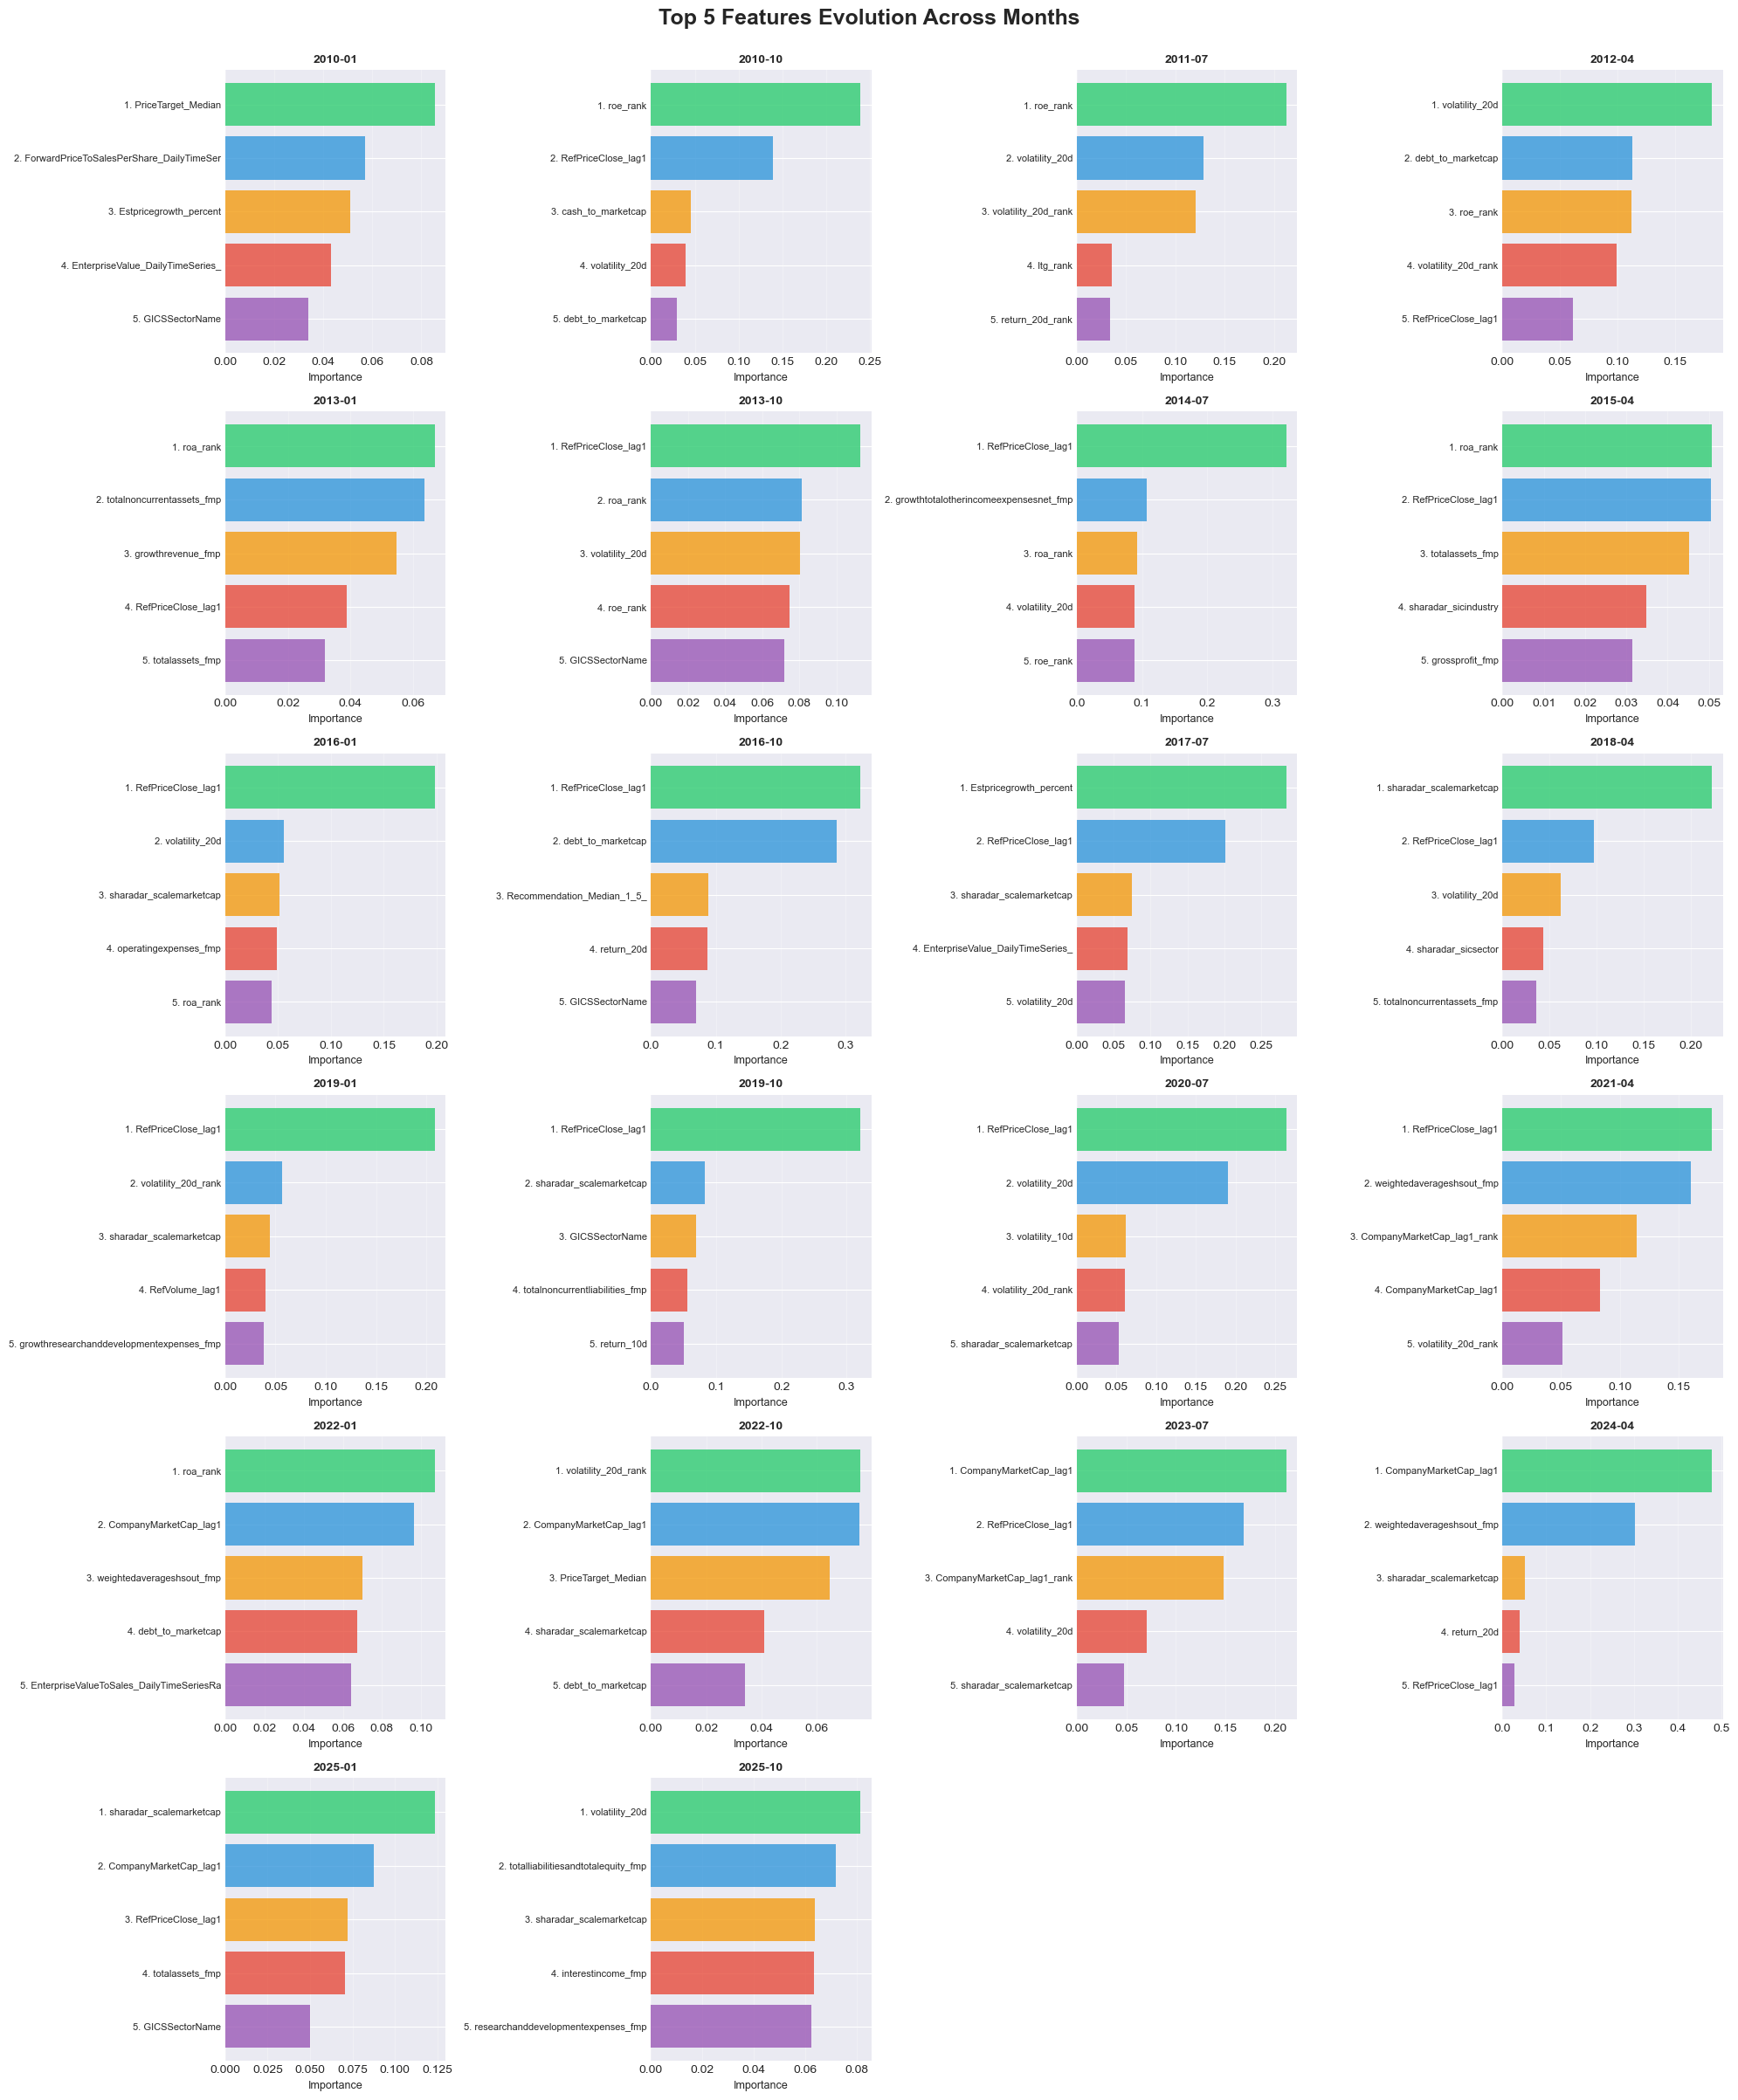


💡 Showing 22 of 193 total months
   Green = Rank 1, Blue = Rank 2, Orange = Rank 3, Red = Rank 4, Purple = Rank 5


In [9]:
# Get top 5 features for each month
top5_per_month = df[df['Rank'] <= 5].copy()

# Get unique months (sample every Nth month if too many)
unique_months = sorted(df['Month'].unique())
sample_interval = max(1, len(unique_months) // 20)  # Show ~20 months max
sampled_months = unique_months[::sample_interval]

# Create subplots
n_months = len(sampled_months)
n_cols = 4
n_rows = (n_months + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 4*n_rows))
axes = axes.flatten() if n_months > 1 else [axes]

for idx, month in enumerate(sampled_months):
    ax = axes[idx]
    
    # Get top 5 for this month
    month_data = top5_per_month[top5_per_month['Month'] == month].sort_values('Rank')
    
    # Create horizontal bar chart
    colors = ['#2ecc71', '#3498db', '#f39c12', '#e74c3c', '#9b59b6'][:len(month_data)]
    
    ax.barh(range(len(month_data)), 
            month_data['Importance'].values,
            color=colors,
            alpha=0.8)
    
    ax.set_yticks(range(len(month_data)))
    ax.set_yticklabels([f"{rank}. {feat[:40]}" 
                        for rank, feat in zip(month_data['Rank'], month_data['Feature'])],
                       fontsize=8)
    ax.set_xlabel('Importance', fontsize=9)
    ax.set_title(f'{month}', fontsize=10, fontweight='bold')
    ax.grid(axis='x', alpha=0.3)
    ax.invert_yaxis()

# Hide unused subplots
for idx in range(len(sampled_months), len(axes)):
    axes[idx].set_visible(False)

fig.suptitle('Top 5 Features Evolution Across Months', 
             fontsize=18, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

print(f"\n💡 Showing {len(sampled_months)} of {len(unique_months)} total months")
print(f"   Green = Rank 1, Blue = Rank 2, Orange = Rank 3, Red = Rank 4, Purple = Rank 5")

## 9. Feature Category Analysis

Group features by type and analyze category importance over time.

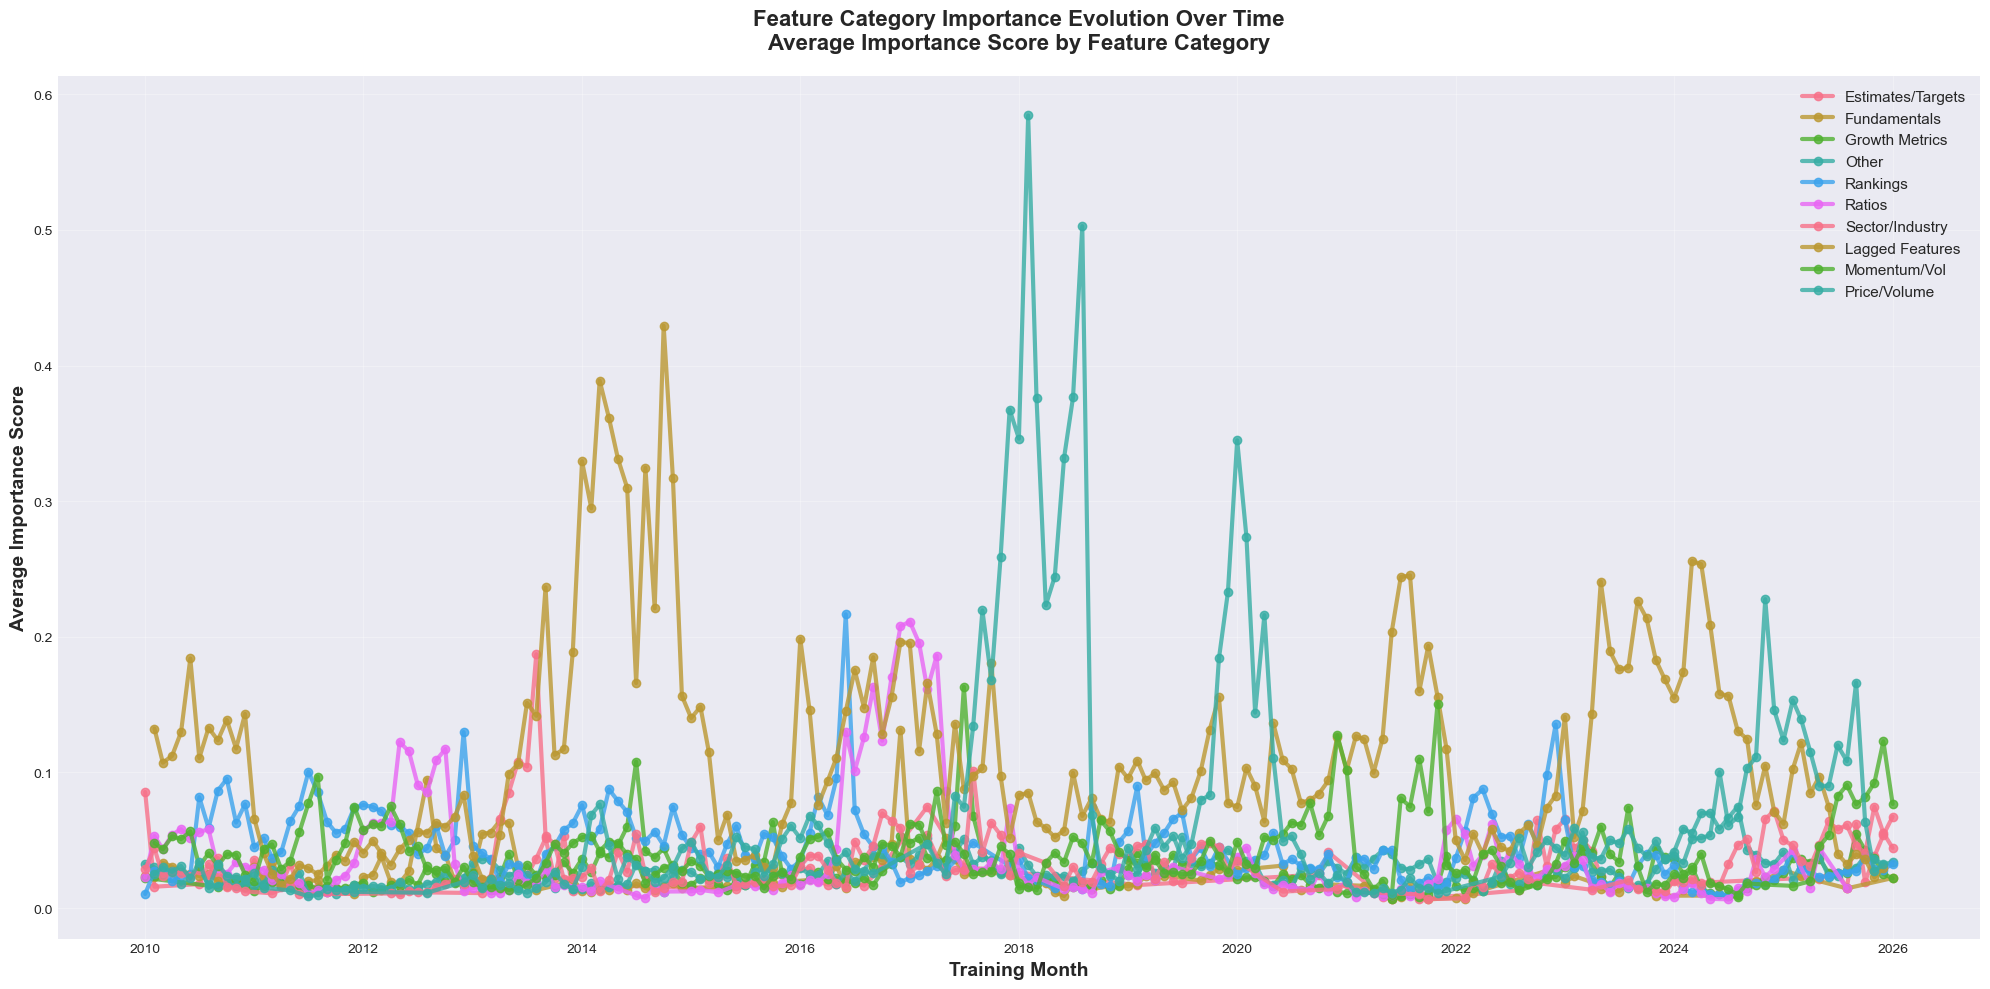


📊 Feature Category Statistics

                   Unique_Features  Avg_Importance  Std_Importance  Avg_Rank  \
Category                                                                       
Lagged Features                  6          0.1087          0.1089    5.7338   
Price/Volume                     1          0.0718          0.0938    6.9341   
Rankings                         8          0.0453          0.0436    9.0795   
Ratios                          12          0.0402          0.0551   11.3003   
Momentum/Vol                     8          0.0401          0.0384    9.8986   
Sector/Industry                  4          0.0309          0.0221   10.8230   
Other                           71          0.0292          0.0292   11.9008   
Estimates/Targets                5          0.0265          0.0181   11.4945   
Growth Metrics                  52          0.0250          0.0207   12.8742   
Fundamentals                    25          0.0243          0.0187   13.1450   

       

In [10]:
def categorize_feature(feature_name):
    """
    Categorize features by type based on name patterns.
    """
    feature_lower = feature_name.lower()
    
    # Categorical features
    if any(x in feature_lower for x in ['sector', 'industry', 'gics']):
        return 'Sector/Industry'
    
    # Lagged features
    if '_lag1' in feature_lower or '_lag2' in feature_lower:
        return 'Lagged Features'
    
    # Ranking features
    if '_rank' in feature_lower or 'rank' in feature_lower:
        return 'Rankings'
    
    # Ratio features
    if '_to_' in feature_lower or 'ratio' in feature_lower:
        return 'Ratios'
    
    # Momentum/volatility
    if any(x in feature_lower for x in ['momentum', 'volatility', 'return']):
        return 'Momentum/Vol'
    
    # Growth features
    if 'growth' in feature_lower:
        return 'Growth Metrics'
    
    # Estimates/targets
    if any(x in feature_lower for x in ['estimate', 'target', 'forward']):
        return 'Estimates/Targets'
    
    # Fundamentals
    if any(x in feature_lower for x in ['earnings', 'revenue', 'ebitda', 'cash', 'debt']):
        return 'Fundamentals'
    
    # Price/volume
    if any(x in feature_lower for x in ['price', 'volume', 'marketcap']):
        return 'Price/Volume'
    
    return 'Other'

# Add category column
df['Category'] = df['Feature'].apply(categorize_feature)

# Calculate average importance by category and month
category_importance = df.groupby(['Month', 'Category'])['Importance'].mean().reset_index()
category_importance['MonthDate'] = pd.to_datetime(category_importance['Month'] + '-01')

# Plot category importance evolution
fig, ax = plt.subplots(figsize=(20, 10))

for category in category_importance['Category'].unique():
    cat_data = category_importance[category_importance['Category'] == category]
    ax.plot(cat_data['MonthDate'],
            cat_data['Importance'],
            marker='o',
            linewidth=3,
            label=category,
            alpha=0.8)

ax.set_title('Feature Category Importance Evolution Over Time\n' +
             'Average Importance Score by Feature Category',
             fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Training Month', fontsize=14, fontweight='bold')
ax.set_ylabel('Average Importance Score', fontsize=14, fontweight='bold')
ax.legend(fontsize=11, framealpha=0.9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Category statistics
print("\n📊 Feature Category Statistics\n")
category_stats = df.groupby('Category').agg({
    'Feature': 'nunique',
    'Importance': ['mean', 'std'],
    'Rank': ['mean', 'median']
}).round(4)
category_stats.columns = ['Unique_Features', 'Avg_Importance', 'Std_Importance', 'Avg_Rank', 'Median_Rank']
category_stats = category_stats.sort_values('Avg_Importance', ascending=False)
print(category_stats)

## 10. Export Summary Statistics

In [ ]:
# Export stability metrics to CSV
mode_suffix = "_fundamentals" if FOCUS_ON_FUNDAMENTALS else "_all"
output_file = feature_importance_file.parent / f"feature_stability_analysis{mode_suffix}_{datetime.now().strftime('%Y%m%d_%H%M%S')}.csv"
df_stability.to_csv(output_file, index=False)

print(f"✅ Stability analysis exported to:")
print(f"   {output_file}")

# Summary
mode_text = " [FUNDAMENTALS FOCUS]" if FOCUS_ON_FUNDAMENTALS else " [ALL FEATURES]"
print(f"\n📋 ANALYSIS SUMMARY{mode_text}")
print(f"   • Total months analyzed: {df['Month'].nunique()}")
print(f"   • Total unique features: {df['Feature'].nunique()}")
print(f"   • Date range: {df['Month'].min()} to {df['Month'].max()}")
if FOCUS_ON_FUNDAMENTALS:
    print(f"   • Excluded features: {', '.join(EXCLUDED_PRICE_FEATURES)}")
print(f"   • Most stable feature: {df_stability.iloc[0]['Feature']}")
print(f"     - Avg rank: {df_stability.iloc[0]['Avg_Rank']:.1f}")
print(f"     - Std rank: {df_stability.iloc[0]['Std_Rank']:.1f}")
print(f"     - Appears in: {df_stability.iloc[0]['Appearance_Pct']:.1f}% of months")
print(f"\n🎯 Best performer: {df_best.iloc[0]['Feature']}")
print(f"     - Avg rank: {df_best.iloc[0]['Avg_Rank']:.1f}")
print(f"     - Top 10 count: {df_best.iloc[0]['Top10_Count']:.0f} times")